# Advanced Topics in Machine Learning - Assignment 0
## Task 3: Understanding GAN Dynamics

This notebook implements a basic Generative Adversarial Network (GAN) on MNIST and then explores common training pathologies like gradient vanishing, mode collapse, and discriminator overfitting.

## Part 1 - Baseline Setup
### Imports

In [1]:
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

os.environ["TQDM_NOTEBOOK"] = "0"
from tqdm import tqdm

warnings.filterwarnings("ignore", category=UserWarning)

### Hyperparameters and Device Configuration

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Training parameters
LEARNING_RATE = 2e-4
BETA1 = 0.5
BETA2 = 0.999
BATCH_SIZE = 128
IMAGE_SIZE = 28 * 28
Z_DIM = 100
NUM_EPOCHS = 50

def set_seed(seed=1337):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(1337)

Using device: cuda


### Data Loading and Preprocessing

In [3]:
transforms_config = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

dataset = datasets.MNIST(root="dataset/", train=True, transform=transforms_config, download=True)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

### Helper Functions for Visualization 📊

In [4]:
def show_images(images, title="Generated Images"):
    """Displays a grid of images."""
    images = images.detach().cpu().numpy() * 0.5 + 0.5
    fig, ax = plt.subplots(figsize=(8, 8))
    grid_img = torchvision.utils.make_grid(torch.from_numpy(images), nrow=8)
    ax.imshow(np.transpose(grid_img.numpy(), (1, 2, 0)))
    ax.set_title(title, fontsize=16)
    ax.axis('off')
    plt.show()

def plot_losses(g_losses, d_losses, title="GAN Loss Curves"):
    """Plots the generator and discriminator loss curves."""
    plt.figure(figsize=(10, 5))
    plt.title(title)
    plt.plot(g_losses, label="Generator Loss")
    plt.plot(d_losses, label="Discriminator Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

fixed_noise = torch.randn(64, Z_DIM).to(device)

### Model Architectures

In [5]:
class Generator(nn.Module):
    def __init__(self, z_dim, img_dim):
        super().__init__()
        self.gen = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, img_dim),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.gen(x)

class Discriminator(nn.Module):
    def __init__(self, img_dim):
        super().__init__()
        self.disc = nn.Sequential(
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.disc(x)

### Initialize Models, Optimizers, and Loss Function

In [6]:
gen = Generator(Z_DIM, IMAGE_SIZE).to(device)
disc = Discriminator(IMAGE_SIZE).to(device)

opt_gen = optim.Adam(gen.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))
opt_disc = optim.Adam(disc.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))
criterion = nn.BCELoss()

### Training Comparison: With and Without Label Smoothing

--- Starting Baseline GAN Training Comparison ---

--- Training WITHOUT Label Smoothing ---


No Smoothing - Epoch [10 out of 50]: 100%|██████████| 469/469 [00:04<00:00, 99.03it/s, d_loss=0.189, g_loss=3.07] 


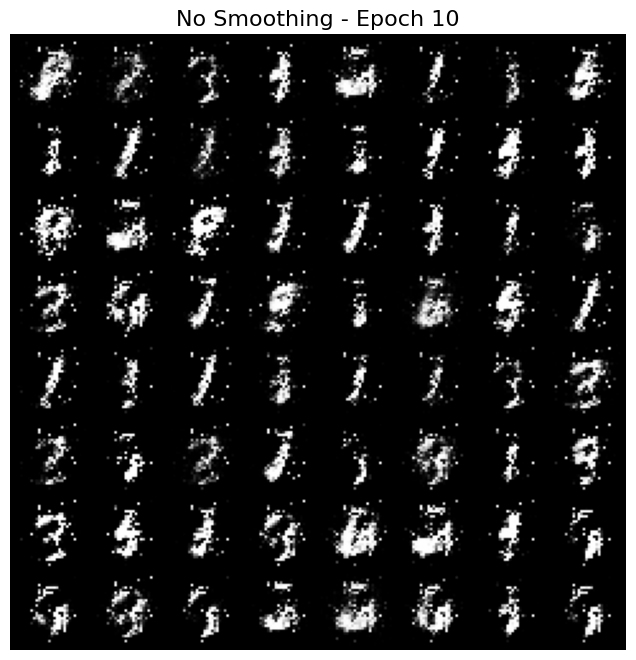

No Smoothing - Epoch [20 out of 50]: 100%|██████████| 469/469 [00:04<00:00, 97.09it/s, d_loss=0.566, g_loss=3.31] 


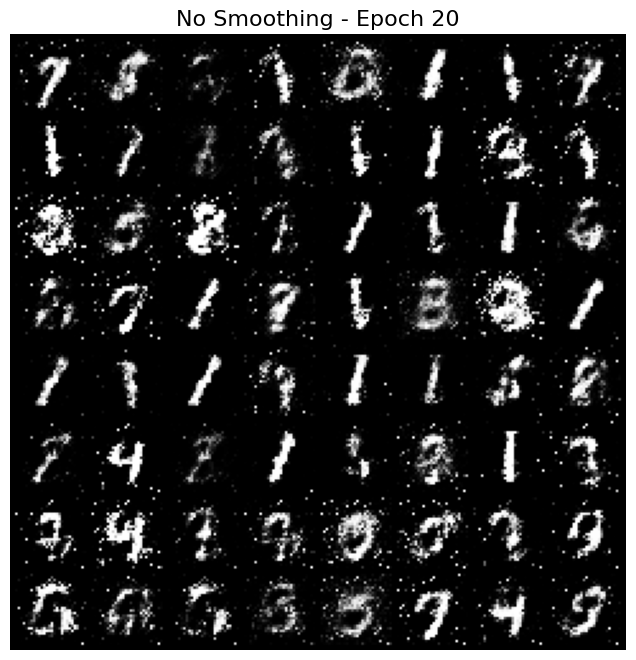

No Smoothing - Epoch [30 out of 50]: 100%|██████████| 469/469 [00:04<00:00, 96.61it/s, d_loss=0.514, g_loss=1.33] 


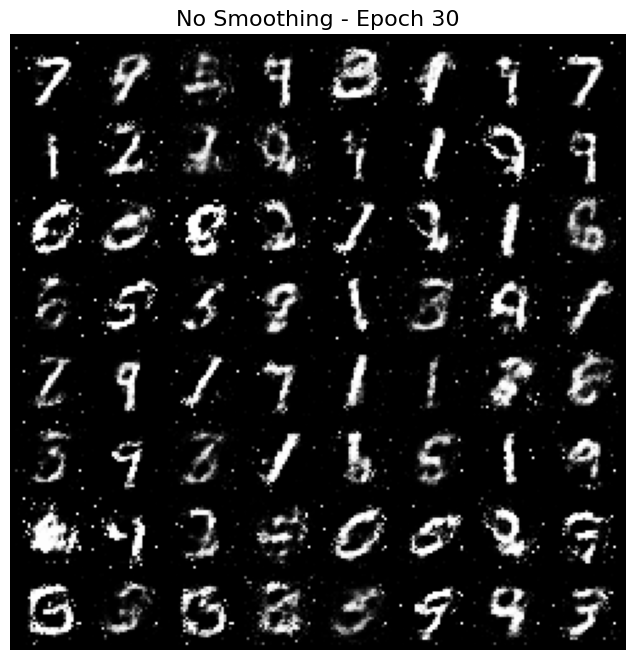

No Smoothing - Epoch [40 out of 50]: 100%|██████████| 469/469 [00:04<00:00, 96.09it/s, d_loss=0.539, g_loss=1.3]  


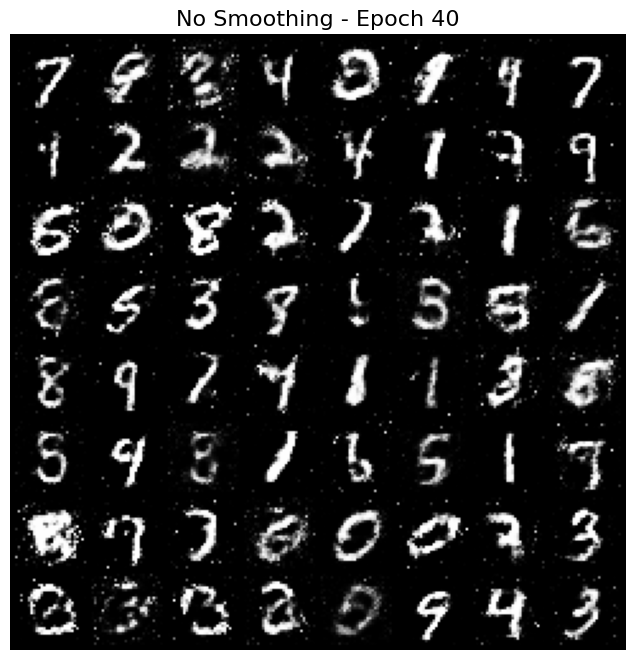

No Smoothing - Epoch [50 out of 50]: 100%|██████████| 469/469 [00:04<00:00, 95.62it/s, d_loss=0.494, g_loss=1.15] 


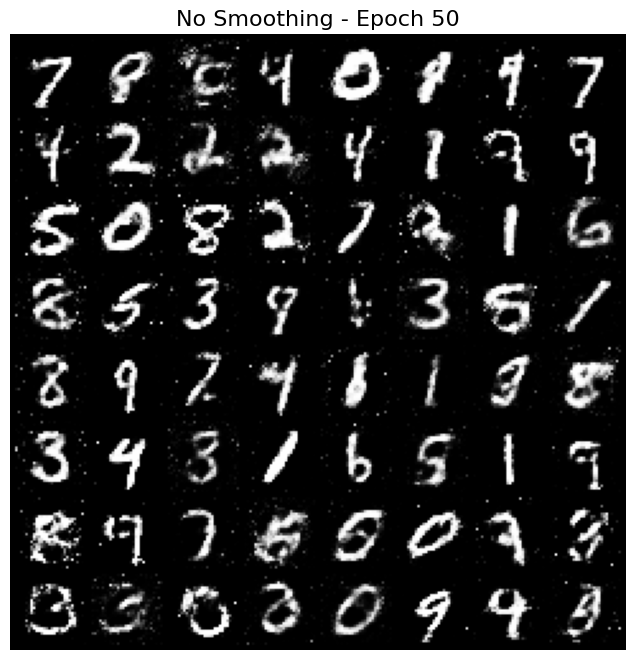

--- Finished Training WITHOUT Label Smoothing ---

--- Training WITH Label Smoothing ---


With Smoothing - Epoch [10 out of 50]: 100%|██████████| 469/469 [00:04<00:00, 99.66it/s, d_loss=0.197, g_loss=5.38] 


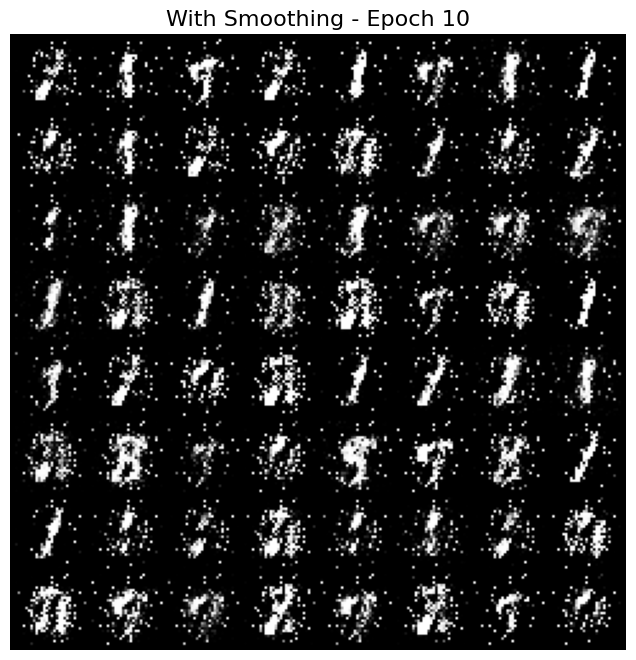

With Smoothing - Epoch [20 out of 50]: 100%|██████████| 469/469 [00:04<00:00, 97.25it/s, d_loss=0.529, g_loss=0.784]


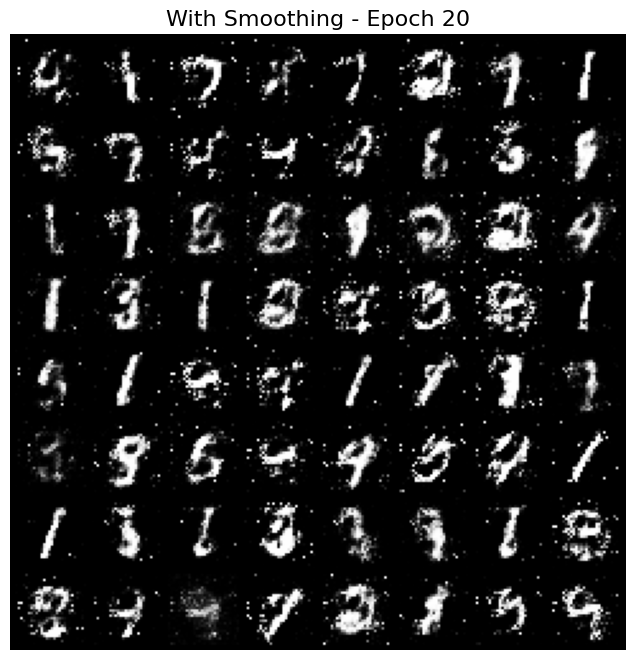

With Smoothing - Epoch [30 out of 50]: 100%|██████████| 469/469 [00:04<00:00, 97.78it/s, d_loss=0.492, g_loss=1.45] 


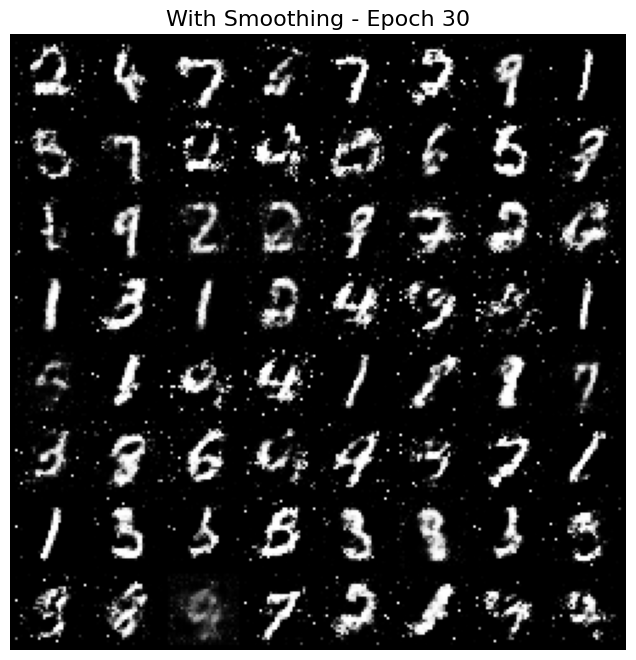

With Smoothing - Epoch [40 out of 50]: 100%|██████████| 469/469 [00:04<00:00, 94.81it/s, d_loss=0.512, g_loss=1.41] 


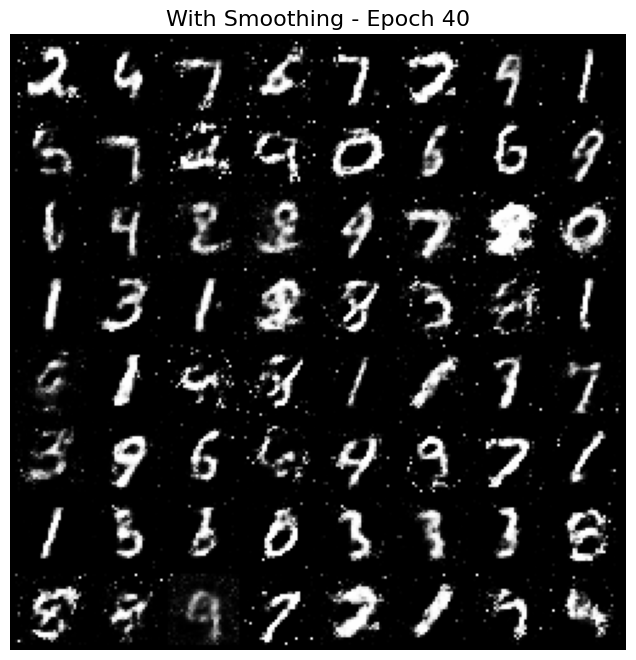

With Smoothing - Epoch [50 out of 50]: 100%|██████████| 469/469 [00:04<00:00, 95.06it/s, d_loss=0.496, g_loss=1.3]  


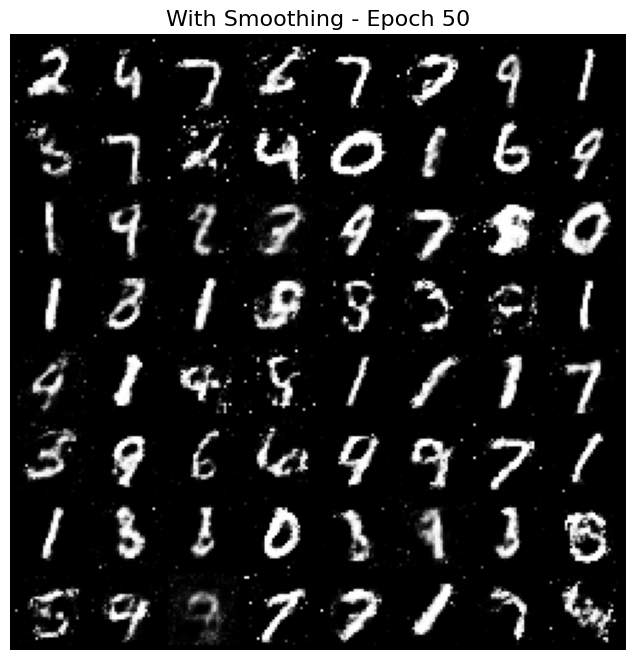

--- Finished Training WITH Label Smoothing ---


In [7]:
print("--- Starting Baseline GAN Training Comparison ---")

# === EXPERIMENT 1: Standard Training (No Label Smoothing) ===
print("\n--- Training WITHOUT Label Smoothing ---")
gen_baseline = Generator(Z_DIM, IMAGE_SIZE).to(device)
disc_baseline = Discriminator(IMAGE_SIZE).to(device)
opt_gen_baseline = optim.Adam(gen_baseline.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))
opt_disc_baseline = optim.Adam(disc_baseline.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))

g_losses_no_smooth = []
d_losses_no_smooth = []

for epoch in range(NUM_EPOCHS):
    loop = tqdm(loader, desc=f"No Smoothing - Epoch [{epoch+1} out of {NUM_EPOCHS}]")
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    num_batches = 0
    
    for batch_idx, (real, _) in enumerate(loop):
        real = real.view(-1, IMAGE_SIZE).to(device)
        batch_size = real.shape[0]

        # --- Train Discriminator ---
        disc_baseline.zero_grad()
        noise = torch.randn(batch_size, Z_DIM).to(device)
        fake = gen_baseline(noise)
        disc_real = disc_baseline(real).view(-1)
        loss_disc_real = criterion(disc_real, torch.ones_like(disc_real))
        disc_fake = disc_baseline(fake.detach()).view(-1)
        loss_disc_fake = criterion(disc_fake, torch.zeros_like(disc_fake))
        loss_disc = (loss_disc_real + loss_disc_fake) / 2
        loss_disc.backward()
        opt_disc_baseline.step()

        # --- Train Generator ---
        gen_baseline.zero_grad()
        output = disc_baseline(fake).view(-1)
        loss_gen = criterion(output, torch.ones_like(output))
        loss_gen.backward()
        opt_gen_baseline.step()

        epoch_g_loss += loss_gen.item()
        epoch_d_loss += loss_disc.item()
        num_batches += 1
        loop.set_postfix(d_loss=loss_disc.item(), g_loss=loss_gen.item())

    if num_batches > 0:
        g_losses_no_smooth.append(epoch_g_loss / num_batches)
        d_losses_no_smooth.append(epoch_d_loss / num_batches)

    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            generated_images = gen_baseline(fixed_noise).view(-1, 1, 28, 28)
            show_images(generated_images, title=f"No Smoothing - Epoch {epoch+1}")

print("--- Finished Training WITHOUT Label Smoothing ---")

# === EXPERIMENT 2: Training WITH Label Smoothing ===
print("\n--- Training WITH Label Smoothing ---")
gen_smooth = Generator(Z_DIM, IMAGE_SIZE).to(device)
disc_smooth = Discriminator(IMAGE_SIZE).to(device)
opt_gen_smooth = optim.Adam(gen_smooth.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))
opt_disc_smooth = optim.Adam(disc_smooth.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))

g_losses_with_smooth = []
d_losses_with_smooth = []

for epoch in range(NUM_EPOCHS):
    loop = tqdm(loader, desc=f"With Smoothing - Epoch [{epoch+1} out of {NUM_EPOCHS}]")
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    num_batches = 0
    
    for batch_idx, (real, _) in enumerate(loop):
        real = real.view(-1, IMAGE_SIZE).to(device)
        batch_size = real.shape[0]

        # --- Train Discriminator ---
        disc_smooth.zero_grad()
        noise = torch.randn(batch_size, Z_DIM).to(device)
        fake = gen_smooth(noise)
        disc_real = disc_smooth(real).view(-1)
        real_labels = torch.ones_like(disc_real) * 0.9 # soft labels (0.9 instead of 1.0)
        loss_disc_real = criterion(disc_real, real_labels)
        disc_fake = disc_smooth(fake.detach()).view(-1)
        loss_disc_fake = criterion(disc_fake, torch.zeros_like(disc_fake))
        loss_disc = (loss_disc_real + loss_disc_fake) / 2
        loss_disc.backward()
        opt_disc_smooth.step()

        # --- Train Generator ---
        gen_smooth.zero_grad()
        output = disc_smooth(fake).view(-1)
        loss_gen = criterion(output, torch.ones_like(output))
        loss_gen.backward()
        opt_gen_smooth.step()

        epoch_g_loss += loss_gen.item()
        epoch_d_loss += loss_disc.item()
        num_batches += 1
        loop.set_postfix(d_loss=loss_disc.item(), g_loss=loss_gen.item())

    if num_batches > 0:
        g_losses_with_smooth.append(epoch_g_loss / num_batches)
        d_losses_with_smooth.append(epoch_d_loss / num_batches)

    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            generated_images = gen_smooth(fixed_noise).view(-1, 1, 28, 28)
            show_images(generated_images, title=f"With Smoothing - Epoch {epoch+1}")

print("--- Finished Training WITH Label Smoothing ---")

### Baseline Results and Discussion


--- Baseline Comparison: Label Smoothing Effects ---


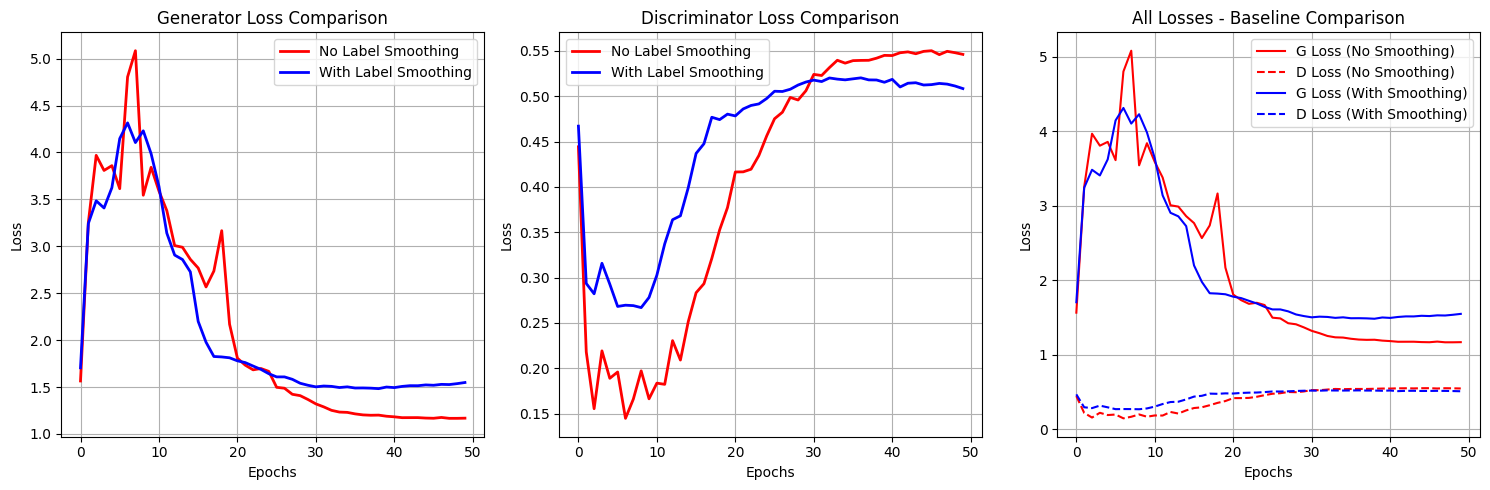


--- Final Generated Images Comparison ---


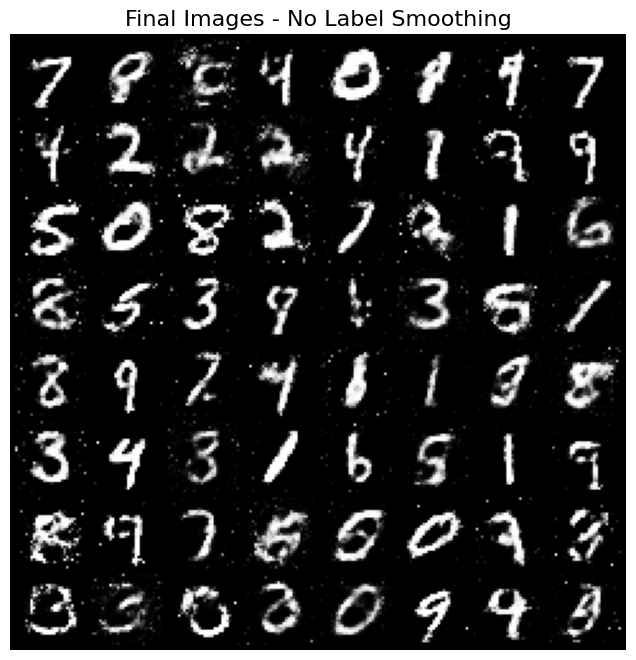

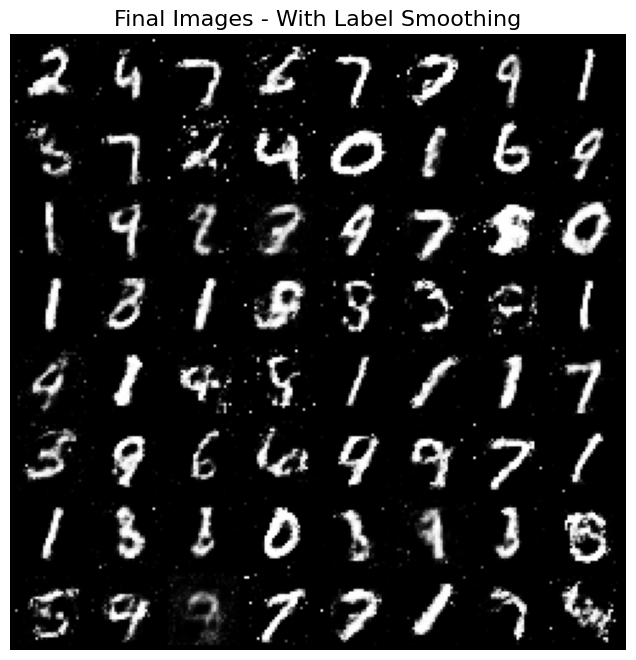


--- Quantitative Analysis ---
Final Generator Loss - No Smoothing: 1.1682
Final Generator Loss - With Smoothing: 1.5483
Final Discriminator Loss - No Smoothing: 0.5462
Final Discriminator Loss - With Smoothing: 0.5085

Average Generator Loss - No Smoothing: 2.1278
Average Generator Loss - With Smoothing: 2.1556
Average Discriminator Loss - No Smoothing: 0.4044
Average Discriminator Loss - With Smoothing: 0.4478

Generator Loss Variance - No Smoothing: 1.2415
Generator Loss Variance - With Smoothing: 0.8587
✅ Label smoothing led to more stable generator training!


In [8]:
print("\n--- Baseline Comparison: Label Smoothing Effects ---")

plt.figure(figsize=(15, 5))

# Generator loss comparison
plt.subplot(1, 3, 1)
plt.plot(g_losses_no_smooth, label="No Label Smoothing", color='red', linewidth=2)
plt.plot(g_losses_with_smooth, label="With Label Smoothing", color='blue', linewidth=2)
plt.title("Generator Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Discriminator loss comparison
plt.subplot(1, 3, 2)
plt.plot(d_losses_no_smooth, label="No Label Smoothing", color='red', linewidth=2)
plt.plot(d_losses_with_smooth, label="With Label Smoothing", color='blue', linewidth=2)
plt.title("Discriminator Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Combined comparison
plt.subplot(1, 3, 3)
plt.plot(g_losses_no_smooth, label="G Loss (No Smoothing)", color='red', linestyle='-')
plt.plot(d_losses_no_smooth, label="D Loss (No Smoothing)", color='red', linestyle='--')
plt.plot(g_losses_with_smooth, label="G Loss (With Smoothing)", color='blue', linestyle='-')
plt.plot(d_losses_with_smooth, label="D Loss (With Smoothing)", color='blue', linestyle='--')
plt.title("All Losses - Baseline Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Final image comparison
print("\n--- Final Generated Images Comparison ---")
with torch.no_grad():
    # Images without smoothing
    final_images_no_smooth = gen_baseline(fixed_noise).view(-1, 1, 28, 28)
    show_images(final_images_no_smooth, title="Final Images - No Label Smoothing")
    
    # Images with smoothing
    final_images_smooth = gen_smooth(fixed_noise).view(-1, 1, 28, 28)
    show_images(final_images_smooth, title="Final Images - With Label Smoothing")

# Quantitative analysis
print("\n--- Quantitative Analysis ---")
print(f"Final Generator Loss - No Smoothing: {g_losses_no_smooth[-1]:.4f}")
print(f"Final Generator Loss - With Smoothing: {g_losses_with_smooth[-1]:.4f}")
print(f"Final Discriminator Loss - No Smoothing: {d_losses_no_smooth[-1]:.4f}")
print(f"Final Discriminator Loss - With Smoothing: {d_losses_with_smooth[-1]:.4f}")

print(f"\nAverage Generator Loss - No Smoothing: {np.mean(g_losses_no_smooth):.4f}")
print(f"Average Generator Loss - With Smoothing: {np.mean(g_losses_with_smooth):.4f}")
print(f"Average Discriminator Loss - No Smoothing: {np.mean(d_losses_no_smooth):.4f}")
print(f"Average Discriminator Loss - With Smoothing: {np.mean(d_losses_with_smooth):.4f}")

# Check training stability
g_variance_no_smooth = np.var(g_losses_no_smooth)
g_variance_with_smooth = np.var(g_losses_with_smooth)
print(f"\nGenerator Loss Variance - No Smoothing: {g_variance_no_smooth:.4f}")
print(f"Generator Loss Variance - With Smoothing: {g_variance_with_smooth:.4f}")

if g_variance_with_smooth < g_variance_no_smooth:
    print("✅ Label smoothing led to more stable generator training!")
else:
    print("❌ Label smoothing didn't improve generator stability")

## 2. Experimenting with Training Issues
### 2.1 Gradient Vanishing

In [9]:
def plot_gan_diagnostics(g_losses, d_losses, dx_scores, dgz_scores, title):
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

    # Plot losses
    ax1.set_title(f"{title} - Loss Curves")
    ax1.plot(g_losses, label="Generator Loss")
    ax1.plot(d_losses, label="Discriminator Loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True)

    # Plot discriminator scores
    ax2.set_title(f"{title} - Discriminator Scores")
    ax2.plot(dx_scores, label="Avg. D(real)")
    ax2.plot(dgz_scores, label="Avg. D(fake)")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Probability")
    ax2.set_ylim(0, 1) 
    ax2.axhline(y=0.5, color="r", linestyle="--", label="Ideal Equilibrium (0.5)")
    ax2.legend()
    ax2.grid(True)

    plt.show()


def train_gradient_vanishing_experiment(
    generator, discriminator, opt_g, opt_d, data_loader, num_epochs,
    d_steps=1, g_steps=1, use_label_smoothing=False, 
    use_saturating_loss=False, title="Experiment"
):
    g_losses, d_losses, dx_scores, dgz_scores = [], [], [], []
    print(f"\n--- Starting Experiment: {title} ---")

    eps = 1e-8

    for epoch in range(num_epochs):
        loop = tqdm(data_loader, desc=f"Epoch [{epoch+1} out of {num_epochs}]")
        epoch_g_loss = epoch_d_loss = epoch_dx = epoch_dgz = 0.0
        num_batches = 0

        for _, (real, _) in enumerate(loop):
            real = real.view(-1, IMAGE_SIZE).to(device)
            batch_size = real.size(0)

            # Train Discriminator
            batch_d_loss = 0.0
            for _ in range(d_steps):
                discriminator.zero_grad()

                # Real images
                disc_real = discriminator(real).view(-1)
                real_labels = torch.ones_like(disc_real)
                if use_label_smoothing:
                    real_labels *= 0.9
                loss_real = criterion(disc_real, real_labels)

                # Fake images
                noise = torch.randn(batch_size, Z_DIM, device=device)
                fake = generator(noise)
                disc_fake = discriminator(fake.detach()).view(-1)
                loss_fake = criterion(disc_fake, torch.zeros_like(disc_fake))

                loss_disc = (loss_real + loss_fake) / 2
                loss_disc.backward()
                opt_d.step()

                batch_d_loss += loss_disc.item()
                epoch_dx += disc_real.mean().item()
                epoch_dgz += disc_fake.mean().item()

            # Train Generator
            batch_g_loss = 0.0
            for _ in range(g_steps):
                generator.zero_grad()
                noise = torch.randn(batch_size, Z_DIM, device=device)
                fake = generator(noise)
                output = discriminator(fake).view(-1)

                if use_saturating_loss:
                    # Saturating loss: min_G log(1 - D(G(z))) 
                    # Implemented as BCE with fake labels (0)
                    loss_gen_opt = criterion(output, torch.zeros_like(output))
                    loss_gen_opt.backward()
                    
                    # For display only: non-saturating equivalent for better visualization
                    with torch.no_grad():
                        display_loss = -torch.mean(torch.log(torch.clamp(output.detach(), min=eps)))
                        batch_g_loss += display_loss.item()
                else:
                    # Non-saturating loss: max_G log(D(G(z)))
                    # Implemented as BCE with real labels (1)
                    loss_gen = criterion(output, torch.ones_like(output))
                    loss_gen.backward()
                    batch_g_loss += loss_gen.item()

                opt_g.step()

            avg_d_loss = batch_d_loss / d_steps
            avg_g_loss = batch_g_loss / g_steps
            epoch_d_loss += avg_d_loss
            epoch_g_loss += avg_g_loss
            num_batches += 1

            loop.set_postfix(d_loss=avg_d_loss, g_loss=avg_g_loss)

        if num_batches > 0:
            d_losses.append(epoch_d_loss / num_batches)
            g_losses.append(epoch_g_loss / num_batches)
            dx_scores.append(epoch_dx / (num_batches * d_steps))
            dgz_scores.append(epoch_dgz / (num_batches * d_steps))

    print(f"--- Finished Experiment: {title} ---")
    plot_gan_diagnostics(g_losses, d_losses, dx_scores, dgz_scores, title)
    
    with torch.no_grad():
        imgs = generator(fixed_noise.to(device)).view(-1, 1, 28, 28)
        show_images(imgs, title=f"Final Images - {title}")


=== Inducing Vanishing Gradients===

--- Starting Experiment: Inducing Vanishing Gradients (Saturating Loss) ---


Epoch [20 out of 20]: 100%|██████████| 469/469 [00:08<00:00, 57.64it/s, d_loss=1.1e-13, g_loss=18.4] 


--- Finished Experiment: Inducing Vanishing Gradients (Saturating Loss) ---


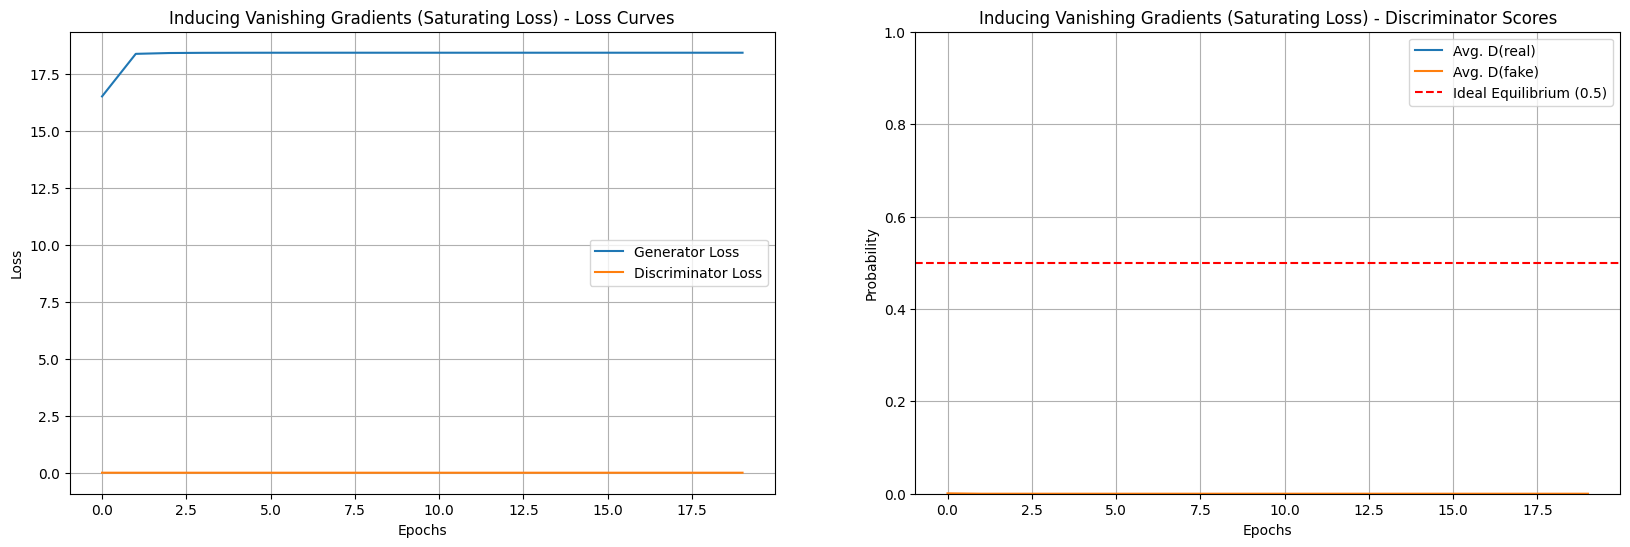

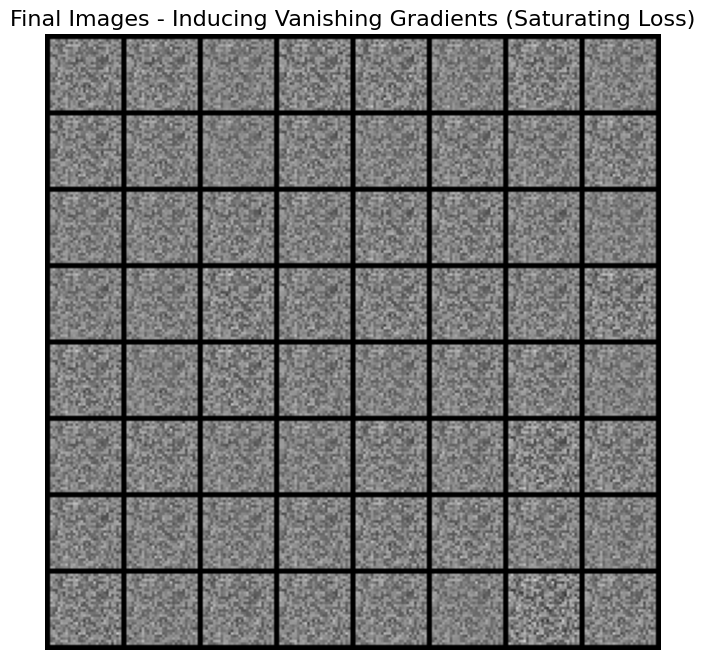


--- Mitigating Vanishing Gradients ---

--- Starting Experiment: Mitigating with Stable Training + Smoothing + Non-Saturating Loss ---


Epoch [20 out of 20]: 100%|██████████| 469/469 [00:04<00:00, 97.39it/s, d_loss=0.407, g_loss=1.89] 


--- Finished Experiment: Mitigating with Stable Training + Smoothing + Non-Saturating Loss ---


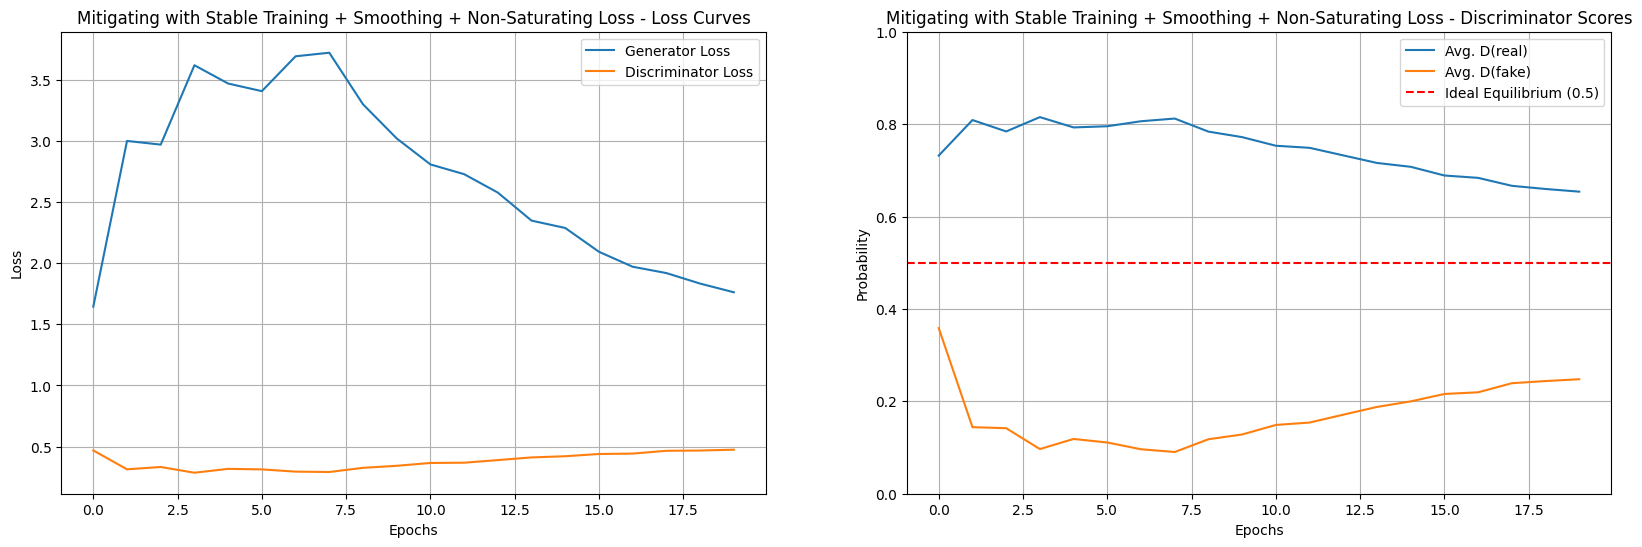

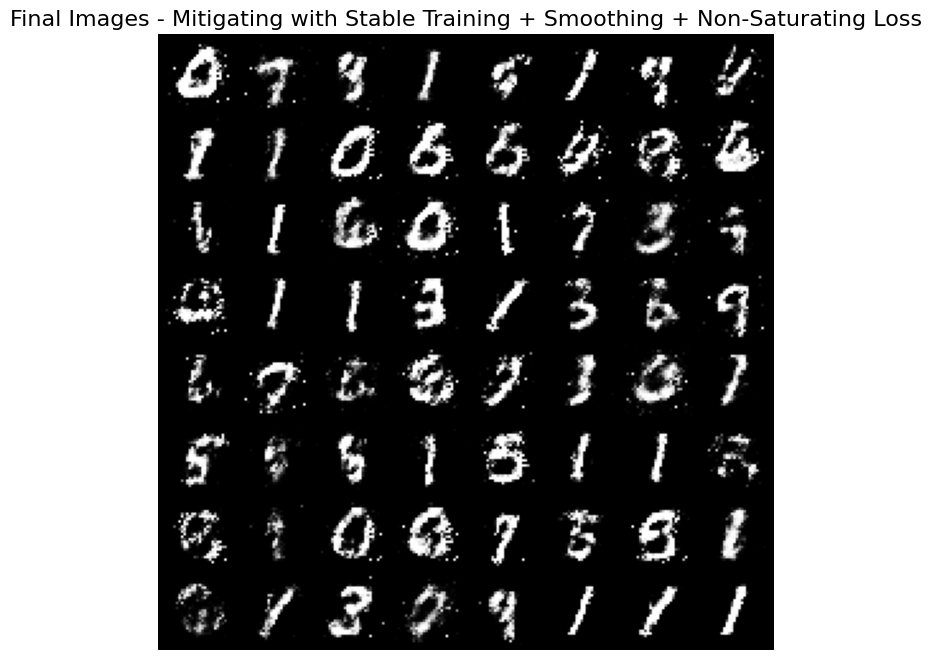

In [10]:
# 1. Induce the textbook vanishing gradient problem
print("\n=== Inducing Vanishing Gradients===")
gen_vg = Generator(Z_DIM, IMAGE_SIZE).to(device)
disc_vg = Discriminator(IMAGE_SIZE).to(device)
opt_gen_vg = optim.Adam(gen_vg.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))
opt_disc_vg = optim.Adam(disc_vg.parameters(), lr=LEARNING_RATE * 10, betas=(BETA1, BETA2))

train_gradient_vanishing_experiment(
    gen_vg, disc_vg, opt_gen_vg, opt_disc_vg, loader,
    num_epochs=20, 
    d_steps=5,
    use_saturating_loss=True,
    title="Inducing Vanishing Gradients (Saturating Loss)"
)

# 2. Mitigate with label smoothing and non-saturating loss
print("\n--- Mitigating Vanishing Gradients ---")
gen_vg_fix = Generator(Z_DIM, IMAGE_SIZE).to(device)
disc_vg_fix = Discriminator(IMAGE_SIZE).to(device)
opt_gen_vg_fix = optim.Adam(gen_vg_fix.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))
opt_disc_vg_fix = optim.Adam(disc_vg_fix.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))

train_gradient_vanishing_experiment(
    gen_vg_fix, disc_vg_fix, opt_gen_vg_fix, opt_disc_vg_fix, loader,
    num_epochs=20, 
    use_label_smoothing=True,
    use_saturating_loss=False,
    title="Mitigating with Stable Training + Smoothing + Non-Saturating Loss"
)

### 2.2 Mode Collapse

In [11]:
def train_mode_collapse_experiment(
    generator, discriminator, opt_g, opt_d, data_loader, num_epochs,
    d_steps=1, g_steps=1, use_label_smoothing=False,
    d_warmup_epochs=0, d_warmup_steps=1,  # Extra D training at start
    instance_noise=0.0, noise_decay_epochs=10,  # Instance noise with decay
    feature_matching_weight=0.0,  # Feature matching strength
    title="Mode Collapse Experiment"
):
    g_losses, d_losses = [], []
    print(f"\n--- Starting Experiment: {title} ---")

    for epoch in range(num_epochs):
        loop = tqdm(data_loader, desc=f"Epoch [{epoch+1} out of {num_epochs}]")
        epoch_g_loss = epoch_d_loss = 0.0
        num_batches = 0

        # Determine current D steps (extra during warmup)
        curr_d_steps = d_warmup_steps if epoch < d_warmup_epochs else d_steps
        
        # Calculate current noise level (decays linearly to 0)
        if instance_noise > 0:
            noise_factor = max(0.0, 1.0 - epoch / max(1, noise_decay_epochs))
            current_noise = instance_noise * noise_factor
        else:
            current_noise = 0.0

        for _, (real, _) in enumerate(loop):
            real = real.view(-1, IMAGE_SIZE).to(device)
            batch_size = real.shape[0]

            # Train Discriminator
            batch_d_loss = 0.0
            real_features = None
            
            for _ in range(curr_d_steps):
                discriminator.zero_grad()

                # Add instance noise if enabled
                real_noisy = real + current_noise * torch.randn_like(real) if current_noise > 0 else real
                disc_real = discriminator(real_noisy).view(-1)
                
                # Label smoothing for real images
                real_labels = torch.ones_like(disc_real)
                if use_label_smoothing:
                    real_labels *= 0.9
                loss_real = criterion(disc_real, real_labels)

                # Fake images with noise
                noise = torch.randn(batch_size, Z_DIM, device=device)
                fake = generator(noise)
                fake_noisy = fake.detach() + current_noise * torch.randn_like(fake) if current_noise > 0 else fake.detach()
                disc_fake = discriminator(fake_noisy).view(-1)
                loss_fake = criterion(disc_fake, torch.zeros_like(disc_fake))

                loss_disc = (loss_real + loss_fake) / 2
                loss_disc.backward()
                opt_d.step()
                batch_d_loss += loss_disc.item()

                # Store real features for feature matching (from clean images)
                if feature_matching_weight > 0:
                    with torch.no_grad():
                        real_features = real.mean(0)

            # Train Generator
            batch_g_loss = 0.0
            for _ in range(g_steps):
                generator.zero_grad()
                noise = torch.randn(batch_size, Z_DIM, device=device)
                fake = generator(noise)
                output = discriminator(fake).view(-1)

                # Standard non-saturating loss
                loss_gen = criterion(output, torch.ones_like(output))

                # Add feature matching if enabled
                if feature_matching_weight > 0 and real_features is not None:
                    fake_features = fake.mean(0)
                    feature_loss = torch.mean((fake_features - real_features)**2)
                    loss_gen = loss_gen + feature_matching_weight * feature_loss

                loss_gen.backward()
                opt_g.step()
                batch_g_loss += loss_gen.item()

            avg_d_loss = batch_d_loss / curr_d_steps
            avg_g_loss = batch_g_loss / g_steps
            epoch_d_loss += avg_d_loss
            epoch_g_loss += avg_g_loss
            num_batches += 1

            loop.set_postfix(
                d_loss=avg_d_loss, 
                g_loss=avg_g_loss, 
                noise=f"{current_noise:.3f}"
            )

        if num_batches > 0:
            g_losses.append(epoch_g_loss / num_batches)
            d_losses.append(epoch_d_loss / num_batches)

    print(f"--- Finished Experiment: {title} ---")
    plot_losses(g_losses, d_losses, title=f"{title} - Loss Curves")
    
    with torch.no_grad():
        generated_images = generator(fixed_noise.to(device)).view(-1, 1, 28, 28)
        show_images(generated_images, title=f"Final Images - {title}")


=== Experiment 2: Mode Collapse ===

--- Starting Experiment: Inducing Mode Collapse (High G Learning Rate) ---


Epoch [20 out of 20]: 100%|██████████| 469/469 [00:04<00:00, 95.18it/s, d_loss=1.68e-6, g_loss=13.9, noise=0.000]


--- Finished Experiment: Inducing Mode Collapse (High G Learning Rate) ---


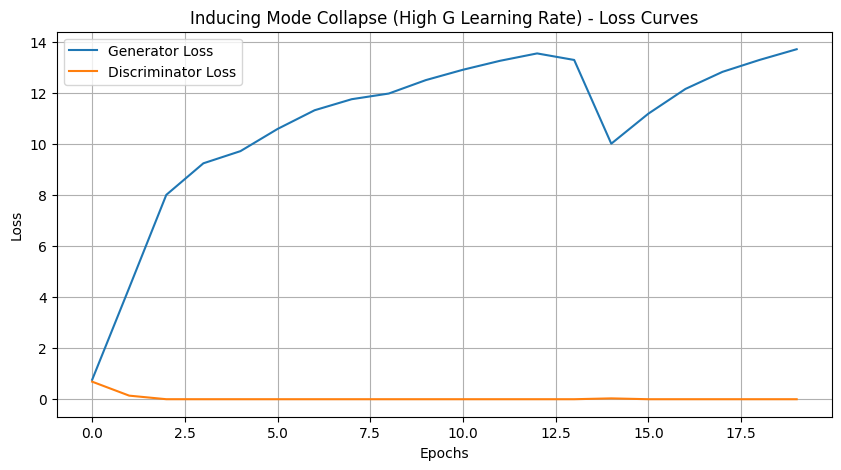

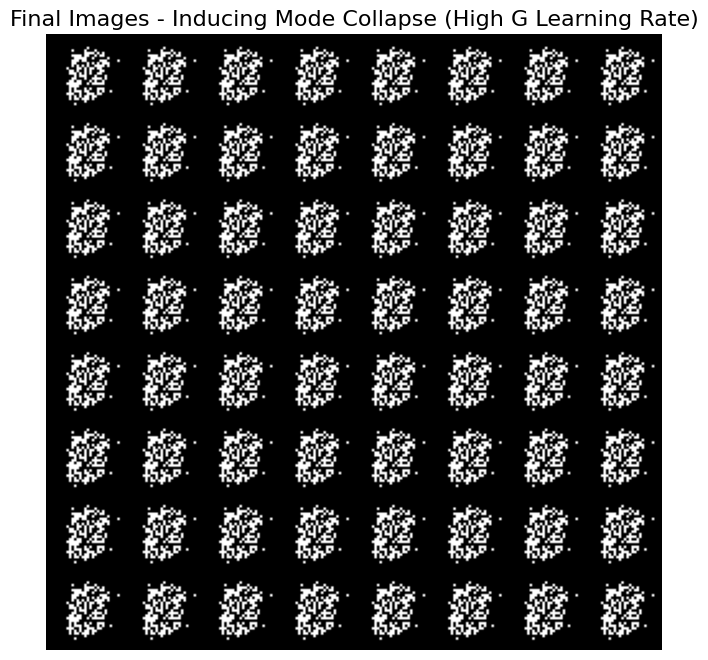


--- Mitigating Mode Collapse ---

--- Starting Experiment: Mitigating Mode Collapse (TTUR + Noise + Feature Matching) ---


Epoch [20 out of 20]: 100%|██████████| 469/469 [00:04<00:00, 93.82it/s, d_loss=0.465, g_loss=2.73, noise=0.000] 


--- Finished Experiment: Mitigating Mode Collapse (TTUR + Noise + Feature Matching) ---


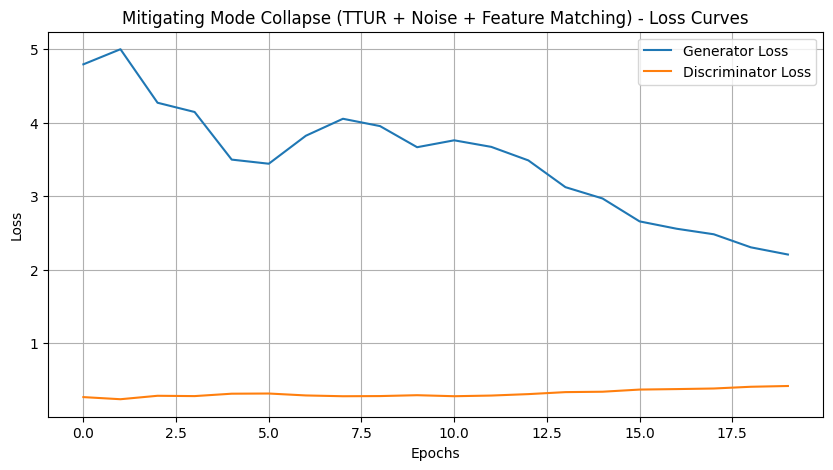

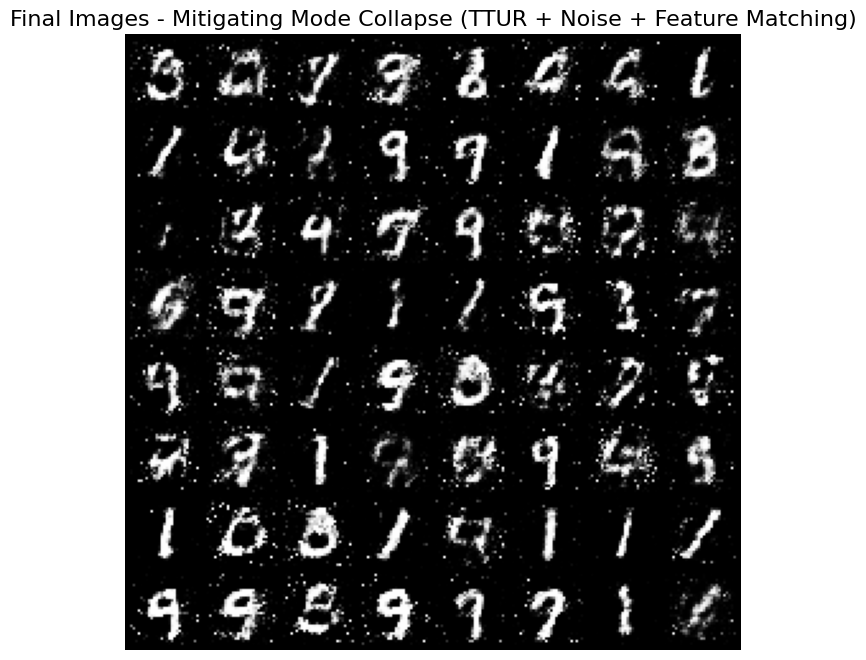

In [12]:
# 1. Induce mode collapse
print("\n=== Experiment 2: Mode Collapse ===")
gen_mc = Generator(Z_DIM, IMAGE_SIZE).to(device)
disc_mc = Discriminator(IMAGE_SIZE).to(device)
opt_gen_mc = optim.Adam(gen_mc.parameters(), lr=LEARNING_RATE * 10, betas=(BETA1, BETA2))
opt_disc_mc = optim.Adam(disc_mc.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))

train_mode_collapse_experiment(
    gen_mc, disc_mc, opt_gen_mc, opt_disc_mc, loader,
    num_epochs=20,
    title="Inducing Mode Collapse (High G Learning Rate)"
)

# 2. Mitigate mode collapse
print("\n--- Mitigating Mode Collapse ---")
gen_mc_fix = Generator(Z_DIM, IMAGE_SIZE).to(device)
disc_mc_fix = Discriminator(IMAGE_SIZE).to(device)

opt_gen_mc_fix = optim.Adam(gen_mc_fix.parameters(), lr=LEARNING_RATE * 0.5, betas=(BETA1, BETA2))
opt_disc_mc_fix = optim.Adam(disc_mc_fix.parameters(), lr=LEARNING_RATE * 1.0, betas=(BETA1, BETA2))

train_mode_collapse_experiment(
    gen_mc_fix, disc_mc_fix, opt_gen_mc_fix, opt_disc_mc_fix, loader,
    num_epochs=20,
    d_warmup_epochs=2,           # Extra D training for first 2 epochs
    d_warmup_steps=3,           # 3 D steps during warmup
    instance_noise=0.10,        # Start with 10% noise
    noise_decay_epochs=12,      # Decay over 12 epochs
    use_label_smoothing=True,   # Smooth real labels
    feature_matching_weight=10.0,  # Enable feature matching
    title="Mitigating Mode Collapse (TTUR + Noise + Feature Matching)"
)

### 2.3 Discriminator Overfitting

In [13]:
def train_discriminator_overfitting_experiment(
    generator, discriminator, opt_g, opt_d, data_loader, num_epochs,
    d_steps=1, g_steps=1, real_label_smooth=0.0, fake_label_smooth=0.0,
    use_logits_loss=True, title="Discriminator Overfitting Experiment"
):
    if use_logits_loss:
        criterion_local = nn.BCEWithLogitsLoss()
    else:
        criterion_local = nn.BCELoss()
    
    g_losses, d_losses = [], []
    print(f"\n--- Starting Experiment: {title} ---")

    for epoch in range(num_epochs):
        loop = tqdm(data_loader, desc=f"Epoch [{epoch+1} out of {num_epochs}]")
        epoch_g_loss = epoch_d_loss = 0.0
        num_batches = 0

        for real, _ in loop:
            real = real.view(-1, IMAGE_SIZE).to(device)
            batch_size = real.size(0)

            # Train Discriminator
            batch_d_loss = 0.0
            for _ in range(d_steps):
                discriminator.zero_grad()

                # Real images
                d_real = discriminator(real).view(-1)
                y_real = torch.ones_like(d_real)
                if real_label_smooth > 0:
                    y_real = y_real * (1.0 - real_label_smooth)
                loss_real = criterion_local(d_real, y_real)

                # Fake images
                noise = torch.randn(batch_size, Z_DIM, device=device)
                fake = generator(noise)
                d_fake = discriminator(fake.detach()).view(-1)
                y_fake = torch.zeros_like(d_fake)
                if fake_label_smooth > 0:
                    y_fake = y_fake + fake_label_smooth
                loss_fake = criterion_local(d_fake, y_fake)

                d_loss = (loss_real + loss_fake) / 2
                d_loss.backward()
                opt_d.step()
                batch_d_loss += d_loss.item()

            # Train Generator
            batch_g_loss = 0.0
            for _ in range(g_steps):
                generator.zero_grad()
                noise = torch.randn(batch_size, Z_DIM, device=device)
                fake = generator(noise)
                d_out = discriminator(fake).view(-1)
                g_loss = criterion_local(d_out, torch.ones_like(d_out))
                g_loss.backward()
                opt_g.step()
                batch_g_loss += g_loss.item()

            avg_d_loss = batch_d_loss / d_steps
            avg_g_loss = batch_g_loss / g_steps
            epoch_d_loss += avg_d_loss
            epoch_g_loss += avg_g_loss
            num_batches += 1
            loop.set_postfix(d_loss=avg_d_loss, g_loss=avg_g_loss)

        if num_batches > 0:
            g_losses.append(epoch_g_loss / num_batches)
            d_losses.append(epoch_d_loss / num_batches)

    print(f"--- Finished Experiment: {title} ---")
    plot_losses(g_losses, d_losses, title=f"{title} - Loss Curves")
    
    with torch.no_grad():
        imgs = generator(fixed_noise.to(device)).view(-1, 1, 28, 28)
        show_images(imgs, title=f"Final Images - {title}")


class DiscriminatorBalanced(nn.Module):
    """Discriminator with dropout and batch norm for overfitting mitigation."""
    def __init__(self, img_dim, dropout_p=0.2):
        super().__init__()
        self.disc = nn.Sequential(
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(dropout_p),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(dropout_p),
            
            nn.Linear(256, 1)
        )
    
    def forward(self, x):
        return self.disc(x)


=== Experiment 3: Discriminator Overfitting ===
Inducing Discriminator Overfitting...

--- Starting Experiment: Inducing Discriminator Overfitting (Small Dataset) ---


Epoch [100 out of 100]: 100%|██████████| 8/8 [00:00<00:00, 100.06it/s, d_loss=0.789, g_loss=0.872]


--- Finished Experiment: Inducing Discriminator Overfitting (Small Dataset) ---


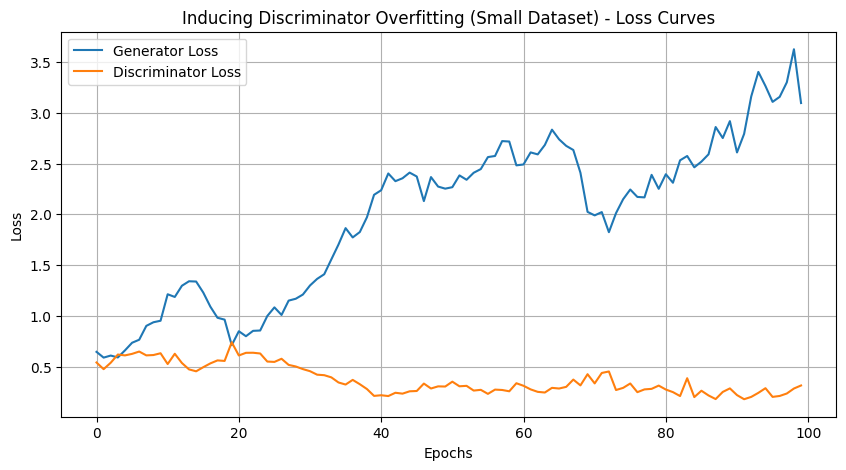

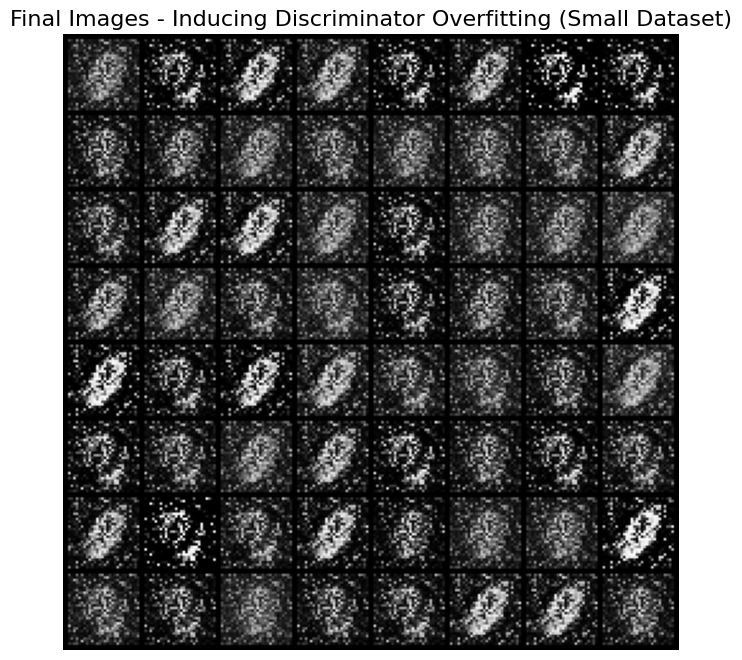


--- Mitigating Discriminator Overfitting ---

--- Starting Experiment: Mitigating Overfitting (Regularized D + Longer Training) ---


Epoch [200 out of 200]: 100%|██████████| 8/8 [00:00<00:00, 95.42it/s, d_loss=0.46, g_loss=1.53]


--- Finished Experiment: Mitigating Overfitting (Regularized D + Longer Training) ---


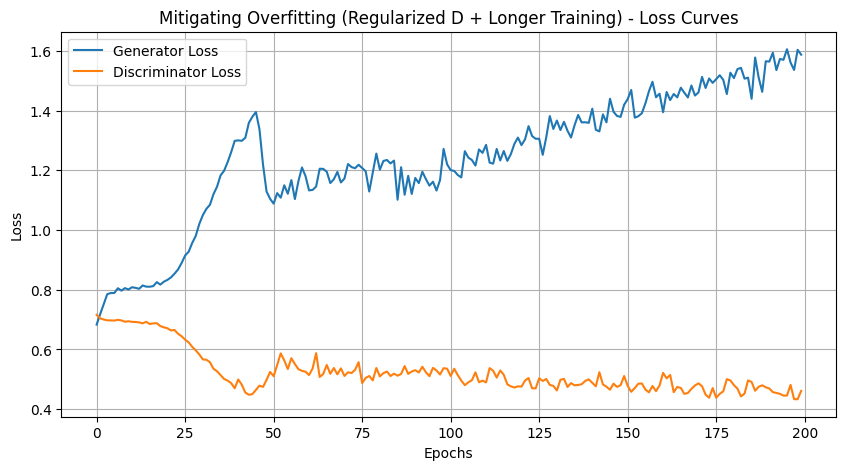

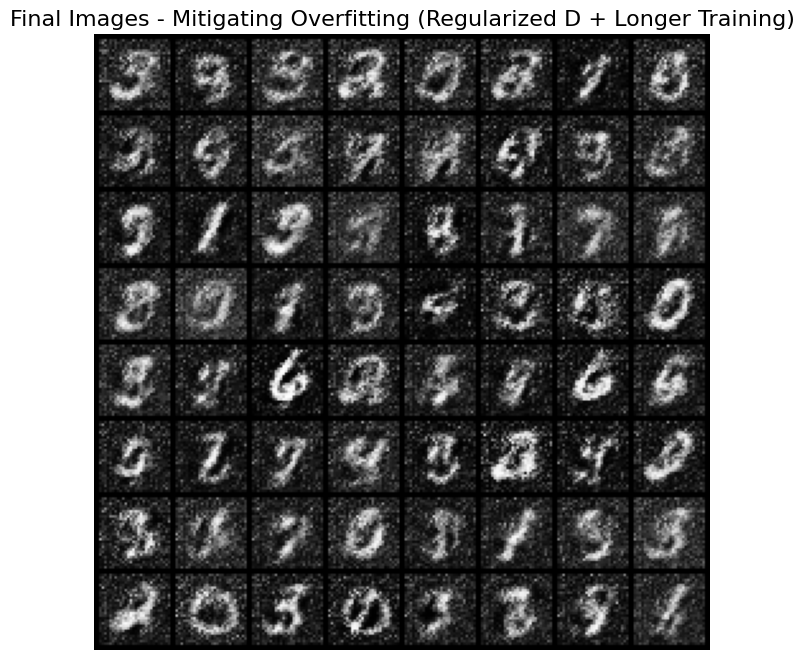


--- All Experiments Complete ---


In [14]:
# Create small dataset for overfitting
print("\n=== Experiment 3: Discriminator Overfitting ===")
subset_indices = range(1000)
small_dataset = Subset(dataset, subset_indices)
small_loader = DataLoader(small_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 1. Induce overfitting with standard discriminator
print("Inducing Discriminator Overfitting...")
gen_of = Generator(Z_DIM, IMAGE_SIZE).to(device)
disc_of = Discriminator(IMAGE_SIZE).to(device)
opt_gen_of = optim.Adam(gen_of.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))
opt_disc_of = optim.Adam(disc_of.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))

train_discriminator_overfitting_experiment(
    gen_of, disc_of, opt_gen_of, opt_disc_of, small_loader,
    num_epochs=100,
    use_logits_loss=False,
    title="Inducing Discriminator Overfitting (Small Dataset)"
)

# 2. Mitigate overfitting with regularized discriminator
print("\n--- Mitigating Discriminator Overfitting ---")
gen_of_fix = Generator(Z_DIM, IMAGE_SIZE).to(device)
disc_of_fix = DiscriminatorBalanced(IMAGE_SIZE, dropout_p=0.2).to(device)
opt_gen_of_fix = optim.Adam(gen_of_fix.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))
opt_disc_of_fix = optim.Adam(disc_of_fix.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))

train_discriminator_overfitting_experiment(
    gen_of_fix, disc_of_fix, opt_gen_of_fix, opt_disc_of_fix, small_loader,
    num_epochs=200,  # Longer training to show recovery
    real_label_smooth=0.1,  # Light label smoothing
    use_logits_loss=True,   # Use logits loss with regularized discriminator
    title="Mitigating Overfitting (Regularized D + Longer Training)"
)

print("\n--- All Experiments Complete ---")